# Prepare the features

- [X] BOP features arrangement and averagings
- [O] Library Features arrangement ad averaging
  average per polihedra.
  average per structure.
  atoms in each polyhedra.
- [X] Matminer features cleanup (decide min, max or avg)
- clear feature list from correlations
- outlier detection based on features
- Feature Distribution plots

# Included averages

- moments of the total density of states :  

$$ m_0^i = \left( \sum_{j} m_j^i \right)/N_{atoms} $$

- CP averaged moments, norm to total number of atoms:

$$ 
   m_{CP}^i =  \left( \sum_{j \in CP} m_j^i \right)/N_{atoms}
$$ 

- CP averaged moments, norm atoms in CP:

$$ 
   m_{CP}^i =  \left( \sum_{j \in CP} m_j^i \right)/N_{CP}
$$ 

# but I should also include:

- correlation matrices for pair of sets

 - input : features dataframes from prev steps
 - output: clean features dataframes into picles

In [1]:
from Tools.DatasetTools.Commoms import *
from Tools.DatasetTools import GeneralFeaturizer as gf
dataset = 'Fe-Mo' #'Fe-Mo' #'Cr-Co-W'
descriptorlocation = os.path.join(dataset, 'Descriptors')
system = dataset.replace('-','')

In [2]:
BS = pd.read_pickle(os.path.join(dataset, 'FullyCuratedParsedBriefSummary.pkl'))

# Load Features 

In [3]:
AtomicFeaturesFile = os.path.join(descriptorlocation, 'matminer_atomic_features.pkl')
CompositionFeaturesFile = os.path.join(descriptorlocation, 'matminer_composition_features.pkl')

Coordination Number averages

In [4]:
PyscalFeaturesFile = os.path.join(descriptorlocation, 'CNAVPyscal.pkl')

In [5]:
bopmodels = ['canonical', 'projections', 'projections_os']
bopfeaturesfile = {model: os.path.join(descriptorlocation, f'curated_{system}_initial_{model}_table_WUBIND_16.pkl') for model in bopmodels}

In [6]:
PyscalFeatures = pd.read_pickle(PyscalFeaturesFile)
BopFeatures = {model: pd.read_pickle(modelfile) for model, modelfile in bopfeaturesfile.items()}
AtomicFeatures = pd.read_pickle(AtomicFeaturesFile)
CompositionFeatures = pd.read_pickle(CompositionFeaturesFile)

# Outlier detection 

I know there are outliers. It is enaugh with looking at the following plots:

In [7]:
BopFeatures['canonical']

,U_bind,U_bond_atom_list_1_0,U_bond_atom_list_1_CN12,U_bond_atom_list_1_CN13,U_bond_atom_list_1_CN14,U_bond_atom_list_1_CN15,U_bond_atom_list_1_CN16,moments_1_0,moments_1_CN12,moments_1_CN13,...,Binf_1_CN13,Binf_1_CN14,Binf_1_CN15,Binf_1_CN16,sf_0,sf_CN12,sf_CN13,sf_CN14,sf_CN15,sf_CN16
Fe_pv8Mo_sv22.sigma-BBABB.FM,-100.702297,-7.906327,-1.428383,0.000000,-6.005237,-0.472706,0.000000,1.174563,0.433709,0.000000,...,0.000000,0.660966,0.164368,0.000000,1.224171,1.311938,0.000000,1.187302,1.155462,0.000000
Fe_pv10Mo_sv20.sigma-ABBAB.FM,-78.594335,-7.771059,-1.424594,0.000000,-5.906606,-0.439859,0.000000,1.201761,0.443751,0.000000,...,0.000000,0.668575,0.166260,0.000000,1.224174,1.311938,0.000000,1.187308,1.155463,0.000000
Fe_pv4Mo_sv20.C36-ABBBB.FM,-94.449166,-8.534487,-7.595698,0.000000,0.000000,0.000000,-0.938789,1.303069,1.079142,0.000000,...,0.000000,0.000000,0.000000,0.501537,1.081732,1.156282,0.000000,0.000000,0.000000,0.901327
Fe_pv5Mo_sv24.chi-AABB.FM,-116.205661,-8.244366,-6.070495,-1.652565,0.000000,0.000000,-0.521305,1.162619,0.589668,0.434727,...,0.451346,0.000000,0.000000,0.186186,1.251703,1.437268,1.179083,0.000000,0.000000,1.006205
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,-121.105805,-8.136275,-2.533063,0.000000,-0.844603,-0.318349,-4.440260,1.218738,0.765044,0.000000,...,0.000000,0.256809,0.124851,0.170809,1.192249,1.343509,0.000000,1.139857,0.956735,0.947607
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv3Mo_sv10.mu-ABBBA.NM,-40.035290,-8.020136,-2.520056,0.000000,-0.663807,-0.397166,-4.439107,1.265062,0.918735,0.000000,...,0.000000,0.220371,0.224323,0.222761,1.071111,1.222567,0.000000,0.902499,0.748344,1.001884
Fe_pv8Mo_sv22.sigma-BBABB.NM,-100.702297,-7.906327,-1.428383,0.000000,-6.005237,-0.472706,0.000000,1.174563,0.433709,0.000000,...,0.000000,0.660966,0.164368,0.000000,1.224171,1.311938,0.000000,1.187302,1.155462,0.000000
Fe_pv1Mo_sv3.L12-AB3.FM,-12.617373,-6.832601,-6.832601,0.000000,0.000000,0.000000,0.000000,1.063750,1.063750,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.140024,1.140024,0.000000,0.000000,0.000000,0.000000
Fe_pv8Mo_sv22.sigma-BBBBA.FM,-94.569986,-7.892530,-5.305761,0.000000,-2.136368,-0.450401,0.000000,1.174563,0.433709,0.000000,...,0.000000,0.660966,0.164368,0.000000,1.224171,1.311938,0.000000,1.187302,1.155462,0.000000


<AxesSubplot:xlabel='U_bond_atom_list_1_0', ylabel='Count'>

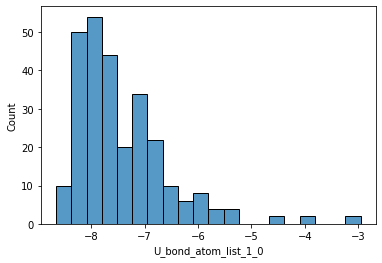

In [8]:
sns.histplot(BopFeatures['canonical']['U_bond_atom_list_1_0'])

# compiling FULL features 

In [9]:
AllFeatures = [AtomicFeatures,CompositionFeatures, BopFeatures['canonical'] ] # 

In [10]:
FullSetOfFeatures = pd.concat(AllFeatures, axis = 1)

# categorical features transformation

In [11]:
from sklearn import set_config
from sklearn.compose import make_column_selector
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import make_pipeline

In [12]:
cat_selector = make_column_selector(dtype_include=object)
categorical_features_names = cat_selector(FullSetOfFeatures)
CategoricalFeatures = FullSetOfFeatures[categorical_features_names]

In [13]:
oencoder = OrdinalEncoder()
oencoder.fit(X=CategoricalFeatures)
replace_categorical_features_values  = oencoder.transform(CategoricalFeatures)

In [14]:
FullSetOfFeatures[categorical_features_names] = replace_categorical_features_values

In [15]:
FullSetOfFeatures[categorical_features_names]

,HOMO_character,HOMO_element,LUMO_character,LUMO_element,compound possible
Fe_pv8.A15.FM,0.0,0.0,0.0,0.0,1.0
Fe_pv12.C14.FM,0.0,0.0,0.0,0.0,1.0
Fe_pv17Mo_sv12.chi-AAAB.FM,0.0,1.0,0.0,1.0,0.0
Fe_pv24Mo_sv5.chi-BBAA.FM,0.0,0.0,0.0,0.0,0.0
Fe_pv25Mo_sv4.chi-ABAA.FM,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...
Fe_pv16Mo_sv8.C36-BBAAA.NM,1.0,0.0,1.0,0.0,0.0
Fe_pv8Mo_sv4.C14-BAA.NM,1.0,0.0,1.0,0.0,0.0
Fe_pv4.fcc-cubic.NM,0.0,0.0,0.0,0.0,1.0
Fe_pv2.hcp.NM,0.0,0.0,0.0,0.0,1.0


# Fix Column Names  

In [16]:
def fix_column_name(thecolumn):
    return thecolumn.replace(' ','_')

In [17]:
columns = FullSetOfFeatures.columns

In [18]:
newcolumns = {col: fix_column_name(col) for col in columns}

In [19]:
FullSetOfFeatures.rename(columns=newcolumns, inplace=True)

In [20]:
FullSetOfFeatures

,MagpieData_minimum_Number,MagpieData_maximum_Number,MagpieData_range_Number,MagpieData_mean_Number,MagpieData_avg_dev_Number,MagpieData_mode_Number,MagpieData_minimum_MendeleevNumber,MagpieData_maximum_MendeleevNumber,MagpieData_range_MendeleevNumber,MagpieData_mean_MendeleevNumber,...,Binf_1_CN13,Binf_1_CN14,Binf_1_CN15,Binf_1_CN16,sf_0,sf_CN12,sf_CN13,sf_CN14,sf_CN15,sf_CN16
Fe_pv8.A15.FM,26.0,26.0,0.0,26.000000,0.000000,26.0,55.0,55.0,0.0,55.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fe_pv12.C14.FM,26.0,26.0,0.0,26.000000,0.000000,26.0,55.0,55.0,0.0,55.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fe_pv17Mo_sv12.chi-AAAB.FM,26.0,42.0,16.0,32.620690,7.762188,26.0,50.0,55.0,5.0,52.931034,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fe_pv24Mo_sv5.chi-BBAA.FM,26.0,42.0,16.0,28.758621,4.565993,26.0,50.0,55.0,5.0,54.137931,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fe_pv25Mo_sv4.chi-ABAA.FM,26.0,42.0,16.0,28.206897,3.804994,26.0,50.0,55.0,5.0,54.310345,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv16Mo_sv8.C36-BBAAA.NM,26.0,42.0,16.0,31.333333,7.111111,26.0,50.0,55.0,5.0,53.333333,...,0.0,0.0,0.0,0.547073,1.081733,1.156284,0.0,0.0,0.0,0.901328
Fe_pv8Mo_sv4.C14-BAA.NM,26.0,42.0,16.0,31.333333,7.111111,26.0,50.0,55.0,5.0,53.333333,...,0.0,0.0,0.0,0.530717,1.106266,1.192873,0.0,0.0,0.0,0.904120
Fe_pv4.fcc-cubic.NM,26.0,26.0,0.0,26.000000,0.000000,26.0,55.0,55.0,0.0,55.000000,...,0.0,0.0,0.0,0.000000,1.140021,1.140021,0.0,0.0,0.0,0.000000
Fe_pv2.hcp.NM,26.0,26.0,0.0,26.000000,0.000000,26.0,55.0,55.0,0.0,55.000000,...,0.0,0.0,0.0,0.000000,1.143628,1.143628,0.0,0.0,0.0,0.000000


# Unsupervised feature selection 

## Variance Threashold

remove features with low variance

TODO: for each separate set of features and save clean pickles

In [21]:
from sklearn.feature_selection import VarianceThreshold

In [22]:
selector = VarianceThreshold()

In [23]:
variance_reduced = selector.fit_transform(FullSetOfFeatures)

/scratch/AnacondaEnvironments/ml_datasets/lib/python3.9/site-packages/sklearn/feature_selection/_variance_threshold.py:104: RuntimeWarning: Degrees of freedom <= 0 for slice.
  self.variances_ = np.nanvar(X, axis=0)
/scratch/AnacondaEnvironments/ml_datasets/lib/python3.9/site-packages/sklearn/feature_selection/_variance_threshold.py:112: RuntimeWarning: All-NaN slice encountered
  self.variances_ = np.nanmin(compare_arr, axis=0)


In [24]:
selectedfeatures = selector.get_support()

In [25]:
AfterVarianceFeatures = FullSetOfFeatures.iloc[:,selectedfeatures]

In [26]:
AfterVarianceFeaturesLocation = os.path.join(descriptorlocation, 'FullSetOfFeatures.pkl')

In [27]:
FullSetOfFeatures.to_pickle(AfterVarianceFeaturesLocation)

#  Correlation based feature selection

this is not started even. 

In [28]:
CORR = AfterVarianceFeatures.corr().abs()

to facilitate higly correlations removal, I will see only the upper triangle of this simmetric matrix

In [29]:
columns = np.full((CORR.shape[0],), True, dtype=bool)

In [30]:
tri_upper_corr = CORR.where(np.triu(np.ones(CORR.shape), k=1).astype(bool))

In [31]:
to_drop = [column for column in tri_upper_corr.columns if any(tri_upper_corr[column] > 0.98)]

In [32]:
len(to_drop)

356

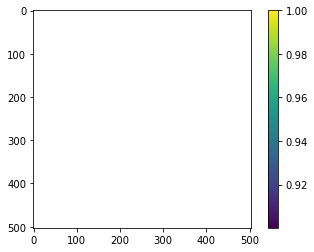

In [33]:
plt.imshow(tri_upper_corr[tri_upper_corr>0.9])
plt.colorbar()

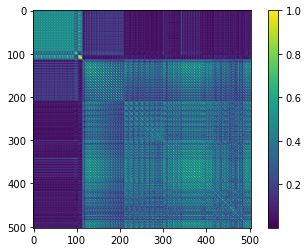

In [34]:
plt.imshow(CORR)
plt.colorbar()